# Assignment 2 - Metabolic Modeling (Week 2)

## Setup and Imports

In [1]:
# run this cell in case of a problem with the imports 
# %pip install pandas cobra escher numpy matplotlib

In [2]:
import cobra as cobra
import pandas as pd 
import escher
from cobra import Reaction
import numpy as np
import matplotlib.pyplot as plt

## Task 1

In [3]:
data = pd.read_csv("KEN3170_Assignment_2026_e_coli_core_expression.csv")
# Strip invisible spaces from the reaction IDs
data["# Reaction ID"] = data["# Reaction ID"].str.strip()
reaction_data = dict(zip(data["# Reaction ID"], data[" reaction activity [mmol/gDW/h] "]))
builder = escher.Builder(map_name="e_coli_core.Core metabolism", reaction_data=reaction_data)
builder
# you still need to load the data by yourself

Builder(reaction_data={'PFK': 13.1, 'PFL': 0.0, 'PGI': 11.1, 'PGK': 24.0, 'PGL': 7.3, 'ACALD': 0.0, 'AKGt2r': …

### Part 1a

In [4]:
# after observing we can notice that "GAPD", "PGK", "PGM", "ENO", "PYK" form a linear pathway
linear_pathway = ["GAPD", "PGK", "PGM", "ENO", "PYK"]
# only include this path
comparison = data[data["# Reaction ID"].isin(linear_pathway)].copy()
# order such that the path has the correct values
comparison["# Reaction ID"] = pd.Categorical(comparison["# Reaction ID"],categories=linear_pathway,ordered=True)
comparison = comparison.sort_values("# Reaction ID")
comparison


,# Reaction ID,reaction activity [mmol/gDW/h]
46,GAPD,24.5
3,PGK,24.0
7,PGM,21.7
30,ENO,29.3
22,PYK,28.2


In [5]:
reaction_data["PGK"]

24.0

In [6]:
# get the activity values
activities = comparison[" reaction activity [mmol/gDW/h] "]
print("Are all activities equal?", activities.nunique() == 1)


Are all activities equal? False


**Conclusion**: As shown above, the **maximal reaction activities differ within the linear pathway**. This is due to the fact that they represent **capacity, but not the flux itself**. Therefore, unlike the steady-state fluxes observed in the interactive session, they are **not required to be equal due to mass balance constraints**.


### Part 1b

In [7]:
model = cobra.io.load_json_model('e_coli_core.json')
model.reactions.get_by_id("PFK")
# the model already defined weather or not a reaction is reversible based on the lower and upper bounds

Reaction identifier,PFK
Name,Phosphofructokinase
Memory address,0x14eb213f620
Stoichiometry,"atp_c + f6p_c --> adp_c + fdp_c + h_c ATP C10H12N5O13P3 + D-Fructose 6-phosphate --> ADP C10H12N5O10P2 + D-Fructose 1,6-bisphosphate + H+"
GPR,b3916 or b1723
Lower bound,0.0
Upper bound,1000.0


We can see some reactions with grey arrows have value 0.00 of maximal reaction activity

In [8]:
zero_reactions = data[data[" reaction activity [mmol/gDW/h] "] == 0]
print(f"Reactions with 0 activity: {len(zero_reactions)}")
print(zero_reactions["# Reaction ID"].values)

Reactions with 0 activity: 12
['PFL' 'ACALD' 'AKGt2r' 'ALCD2x' 'PYRt2' 'SUCCt2_2' 'D_LACt2' 'SUCCt3'
 'FUMt2_2' 'GLUt2r' 'LDH_D' 'MALt2_2']


However, there are more grey arrows than 12 and they marked as nd: no data. So it means in CSV based on which we build the  model, there is no information about these reactions

In [9]:
# Get all reaction IDs in our model
model_rxns = set(r.id for r in model.reactions)

# Get all reaction IDsfrom CSV
csv_rxns = set(data["# Reaction ID"].str.strip())

# Find the difference
missing_from_csv = model_rxns - csv_rxns

print(f"Reactions missing from CSV (nd): {len(missing_from_csv)}")
print(missing_from_csv)

Reactions missing from CSV (nd): 30
{'ACALDt', 'O2t', 'EX_succ_e', 'CO2t', 'EX_glu__L_e', 'FORt', 'ETOHt2r', 'EX_fru_e', 'EX_pi_e', 'BIOMASS_Ecoli_core_w_GAM', 'NH4t', 'EX_co2_e', 'H2Ot', 'FORt2', 'EX_gln__L_e', 'EX_fum_e', 'EX_h_e', 'EX_ac_e', 'EX_akg_e', 'EX_etoh_e', 'EX_pyr_e', 'EX_mal__L_e', 'EX_nh4_e', 'EX_glc__D_e', 'ATPM', 'EX_o2_e', 'EX_acald_e', 'EX_h2o_e', 'EX_for_e', 'EX_lac__D_e'}


**Conclusion**: The grey arrows show either **zero or no data (`nd`)**. Zero represents that the **maximal reaction activity for this reaction is zero**, whereas no data means that it **has not yet been determined in this model (missing information)**.

## Task 2

In [10]:
def modify_bounds(reaction_data,model):

    # leave the lower flux as it is for ATPM
    atpm_lower_bound = model.reactions.get_by_id("ATPM").lower_bound

    for reaction in model.reactions:
        # special case
        if reaction.id == "EX_glc__D_e":
            reaction.lower_bound = -1000.0
            reaction.upper_bound = 1000.0
            continue

        # get all of the reactions that are both in reaction data and model
        if reaction.id in reaction_data:
            value = reaction_data[reaction.id]
            # print(value)
            # reversible reactions
            if reaction.reversibility: #originally reversible
                reaction.lower_bound = - value
                reaction.upper_bound = value
            else: #originally NOT reversible
                reaction.upper_bound = value

    # does high absolute default bound means bounds of lb= -1000 and ub=1000
    # if yes then change - model.reactions.get_by_id("EX_glc__D_e").lower_bound = -1000

    model.reactions.get_by_id("ATPM").lower_bound = atpm_lower_bound
    
    return model
    


In [11]:
model = modify_bounds(reaction_data, model)
bounds_df = pd.DataFrame([{"Reaction": reaction.id,"Lower Bound": reaction.lower_bound,
"Upper Bound": reaction.upper_bound}for reaction in model.reactions])

pd.set_option('display.max_rows', None)
bounds_df

,Reaction,Lower Bound,Upper Bound
0,PFK,0.00,13.10
1,PFL,0.00,0.00
2,PGI,-11.10,11.10
3,PGK,-24.00,24.00
4,PGL,0.00,7.30
5,ACALD,-0.00,0.00
6,AKGt2r,-0.00,0.00
7,PGM,-21.70,21.70
8,PIt2r,-5.20,5.20
9,ALCD2x,-0.00,0.00


## Task 3

### Part 3a

In [12]:
solution_a = model.optimize()
print(f"Maximal biomass rate (expression-based constraints): {solution_a.objective_value}")

Maximal biomass rate (expression-based constraints): 0.8732862458582367


### Part 3b

In contrast to expression-based constraints, new constraint represents an **external** environment limitation, while all other constraints describe **internal** limitations. Expression-based constraints represent maximum physical capacity if unlimited food is available.

We can assume that instead of almost infinite resources, now food is scarce. Since we're talking about uptake reaction, meaning material enters system from outside, we represent it as negative flux, so we set a negative lower bound.

In [13]:
model.reactions.get_by_id("EX_glc__D_e").lower_bound = -5.0
print(f"Glucose exchange new bounds: {model.reactions.get_by_id('EX_glc__D_e').bounds}")

Glucose exchange new bounds: (-5.0, 1000.0)


### Part 3c

In [14]:
solution_c = model.optimize()
print(f"Maximal biomass rate (with glucose limits): {solution_c.objective_value}")

Maximal biomass rate (with glucose limits): 0.41559777509290663


**Conclusion**: the biomass rate value with new limit decreased almost by half of original value. Compared to part a, where major limitation was enzymes, now the amount of food and energy is even more important constraint, slowing the growth of cells.

## Task 4

### Part 4a

In [15]:
# 15.1 is not included, so we get a range from 1 to 15 with 0.1 step
glucose_bounds = np.arange(1.0, 15.1, 0.1)
biomass_rates = []

for bound in glucose_bounds:
    # Set uptake, so negative bound value
    model.reactions.get_by_id("EX_glc__D_e").lower_bound = -bound
    
    # FBA optimization
    solution = model.optimize()
    
    biomass_rates.append(solution.objective_value)

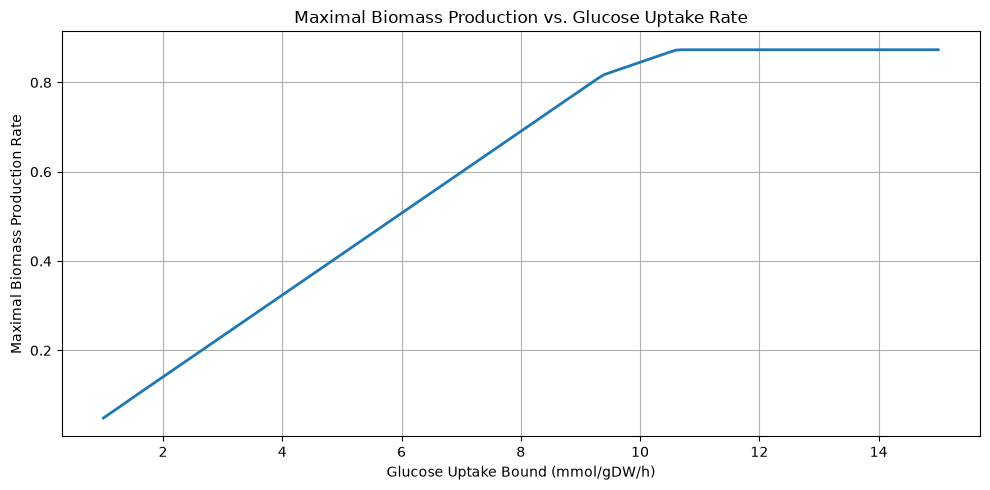

In [25]:
# Make plot a bit bigger size
plt.figure(figsize=(10, 5))
plt.plot(glucose_bounds, biomass_rates, linewidth=2)
plt.title("Maximal Biomass Production vs. Glucose Uptake Rate")
plt.xlabel("Glucose Uptake Bound (mmol/gDW/h)")
plt.ylabel("Maximal Biomass Production Rate")
# Add grid for better visual understanding
plt.grid(True)
plt.tight_layout()
plt.show()

### Part 4b

The plot shows that the growth rate **doesn't** increase indefinitely with increasing glucose exchange reaction flux bound. Up to approximately 9.5 mmol/gDW/h there is a slope, demonstrating the increase of rate. Due to absence of enough food, the cells are starving, so every extra molecule of sugar is used for faster growth.

After that, we see a smaller increase of growth until we reach a plateau at around 11 mmol/gDW/h. At this point, we have enough glucose and cells are fully saturated, so the major constraint becomes enzyme, as it was in original model with unlimited food supply.

### Part 4c

In order to find the activated process in segment 2, we can simply compare activated processes (flux > 0) in segment 1 and 2. The difference will be the process we're looking for.

In [28]:
# Segment 1
model.reactions.get_by_id("EX_glc__D_e").lower_bound = -8
segment_1 = model.optimize()
active_reactions_1 = set(reaction.id for reaction in model.exchanges if abs(segment_1.fluxes[reaction.id]) > 0)

# Segment 2
model.reactions.get_by_id("EX_glc__D_e").lower_bound = -10
segment_2 = model.optimize()
active_reactions_2 = set(reaction.id for reaction in model.exchanges if abs(segment_2.fluxes[reaction.id]) > 0)

new_active = active_reactions_2 - active_reactions_1

print(f"ID of process that gets active in Segment 2: {new_active}")

ID of process that gets active in Segment 2: {'EX_ac_e'}
